In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
from pathlib import Path

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 150

# PTB-XL / PTB-XL+ Keşifsel Veri Analizi
Bu bölümde PTB-XL metadata ve PTB-XL+ 12SL öznitelikleri üzerinde temel dağılımlar, sınıf dengesizliği ve eksik değer profili incelenir.

In [3]:
# Veri yükleme ve etiket oluşturma
base_dir = Path.cwd().parent
db_path = base_dir / "ptb-xl" / "ptbxl_database.csv"
scp_path = base_dir / "ptb-xl" / "scp_statements.csv"
feat_path = base_dir / "ptb-xl+" / "features" / "12sl_features.csv"

db = pd.read_csv(db_path)
scp = pd.read_csv(scp_path, index_col=0)
features = pd.read_csv(feat_path)

db["scp_codes"] = db["scp_codes"].apply(ast.literal_eval)
scp_diag = scp[scp["diagnostic"] == 1]

def get_diagnostic_superclass(codes_dict):
    for code in codes_dict.keys():
        if code in scp_diag.index:
            return scp_diag.loc[code, "diagnostic_class"]
    return None

db["diagnostic_superclass"] = db["scp_codes"].apply(get_diagnostic_superclass)

df = features.merge(
    db[["ecg_id", "age", "sex", "diagnostic_superclass", "strat_fold", "height", "weight"]],
    on="ecg_id",
    how="left",
)

print("=== Data Shapes ===")
print(f"PTB-XL metadata: {db.shape}")
print(f"12SL features: {features.shape}")
print(f"Merged dataset: {df.shape}")

=== Data Shapes ===
PTB-XL metadata: (21799, 29)
12SL features: (21799, 783)
Merged dataset: (21799, 789)


In [4]:
# Özet istatistikler ve eksik değer profili
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "percent": missing_pct})
missing_df = missing_df[missing_df["count"] > 0].sort_values("count", ascending=False)

class_counts = df["diagnostic_superclass"].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

print("=== Missing Values ===")
print(f"Toplam eksik içeren sütun: {len(missing_df)}")
print(missing_df.head(10))

print("\n=== Sınıf Dağılımı ===")
print(class_counts)
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}x")

=== Missing Values ===
Toplam eksik içeren sütun: 11
                       count  percent
height                 14825    68.01
weight                 12378    56.78
P_On_Global             2032     9.32
P_Off_Global            2032     9.32
P_Dur_Global            2032     9.32
PR_Int_Global           2013     9.23
P_AxisFront_Global      1994     9.15
HR_Atrial_Global        1582     7.26
diagnostic_superclass    411     1.89
T_AxisFront_Global         4     0.02

=== Sınıf Dağılımı ===
diagnostic_superclass
NORM    9514
MI      5424
STTC    2817
CD      2325
HYP     1308
Name: count, dtype: int64
Imbalance ratio (max/min): 7.27x


In [5]:
df

,P_Area_I,P_PeakTime_I,Q_Area_I,Q_PeakTime_I,R_Area_I,R_PeakTime_I,S_Area_I,S_PeakTime_I,QRS_Balance_I,T_Area_I,...,P_Dur_Global,P_Found_Global,HR__Global,P_Term_V1,age,sex,diagnostic_superclass,strat_fold,height,weight
0,0.264,64.0,0.000,0.0,0.737,30.0,0.000,0.0,629.0,0.819,...,112.0,1,64.0,0.000,56.0,1,NORM,3,NaN,63.0
1,-0.047,6.0,0.015,8.0,0.794,36.0,1.246,76.0,205.0,2.206,...,66.0,1,75.0,0.000,87.0,1,CD,2,NaN,NaN
2,0.000,0.0,0.000,0.0,0.792,38.0,1.389,74.0,141.0,1.155,...,NaN,0,169.0,0.000,87.0,1,CD,2,NaN,NaN
3,0.196,74.0,0.000,0.0,0.947,56.0,0.000,0.0,439.0,-0.339,...,114.0,1,79.0,0.000,72.0,0,MI,3,NaN,NaN
4,0.287,102.0,0.000,0.0,1.021,36.0,0.000,0.0,937.0,0.756,...,136.0,1,92.0,6.612,85.0,0,STTC,5,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21794,0.220,80.0,0.015,10.0,0.961,38.0,0.000,0.0,620.0,0.852,...,120.0,1,67.0,0.000,300.0,0,NORM,4,NaN,NaN
21795,0.224,78.0,0.012,6.0,1.022,34.0,0.000,0.0,693.0,0.734,...,140.0,1,59.0,2.465,59.0,1,STTC,2,NaN,NaN
21796,0.206,62.0,0.000,0.0,0.789,34.0,0.000,0.0,722.0,0.657,...,110.0,1,70.0,2.418,64.0,1,NORM,8,NaN,NaN
21797,0.119,48.0,0.000,0.0,0.961,36.0,0.000,0.0,937.0,1.200,...,142.0,1,59.0,5.840,68.0,0,NORM,9,NaN,NaN


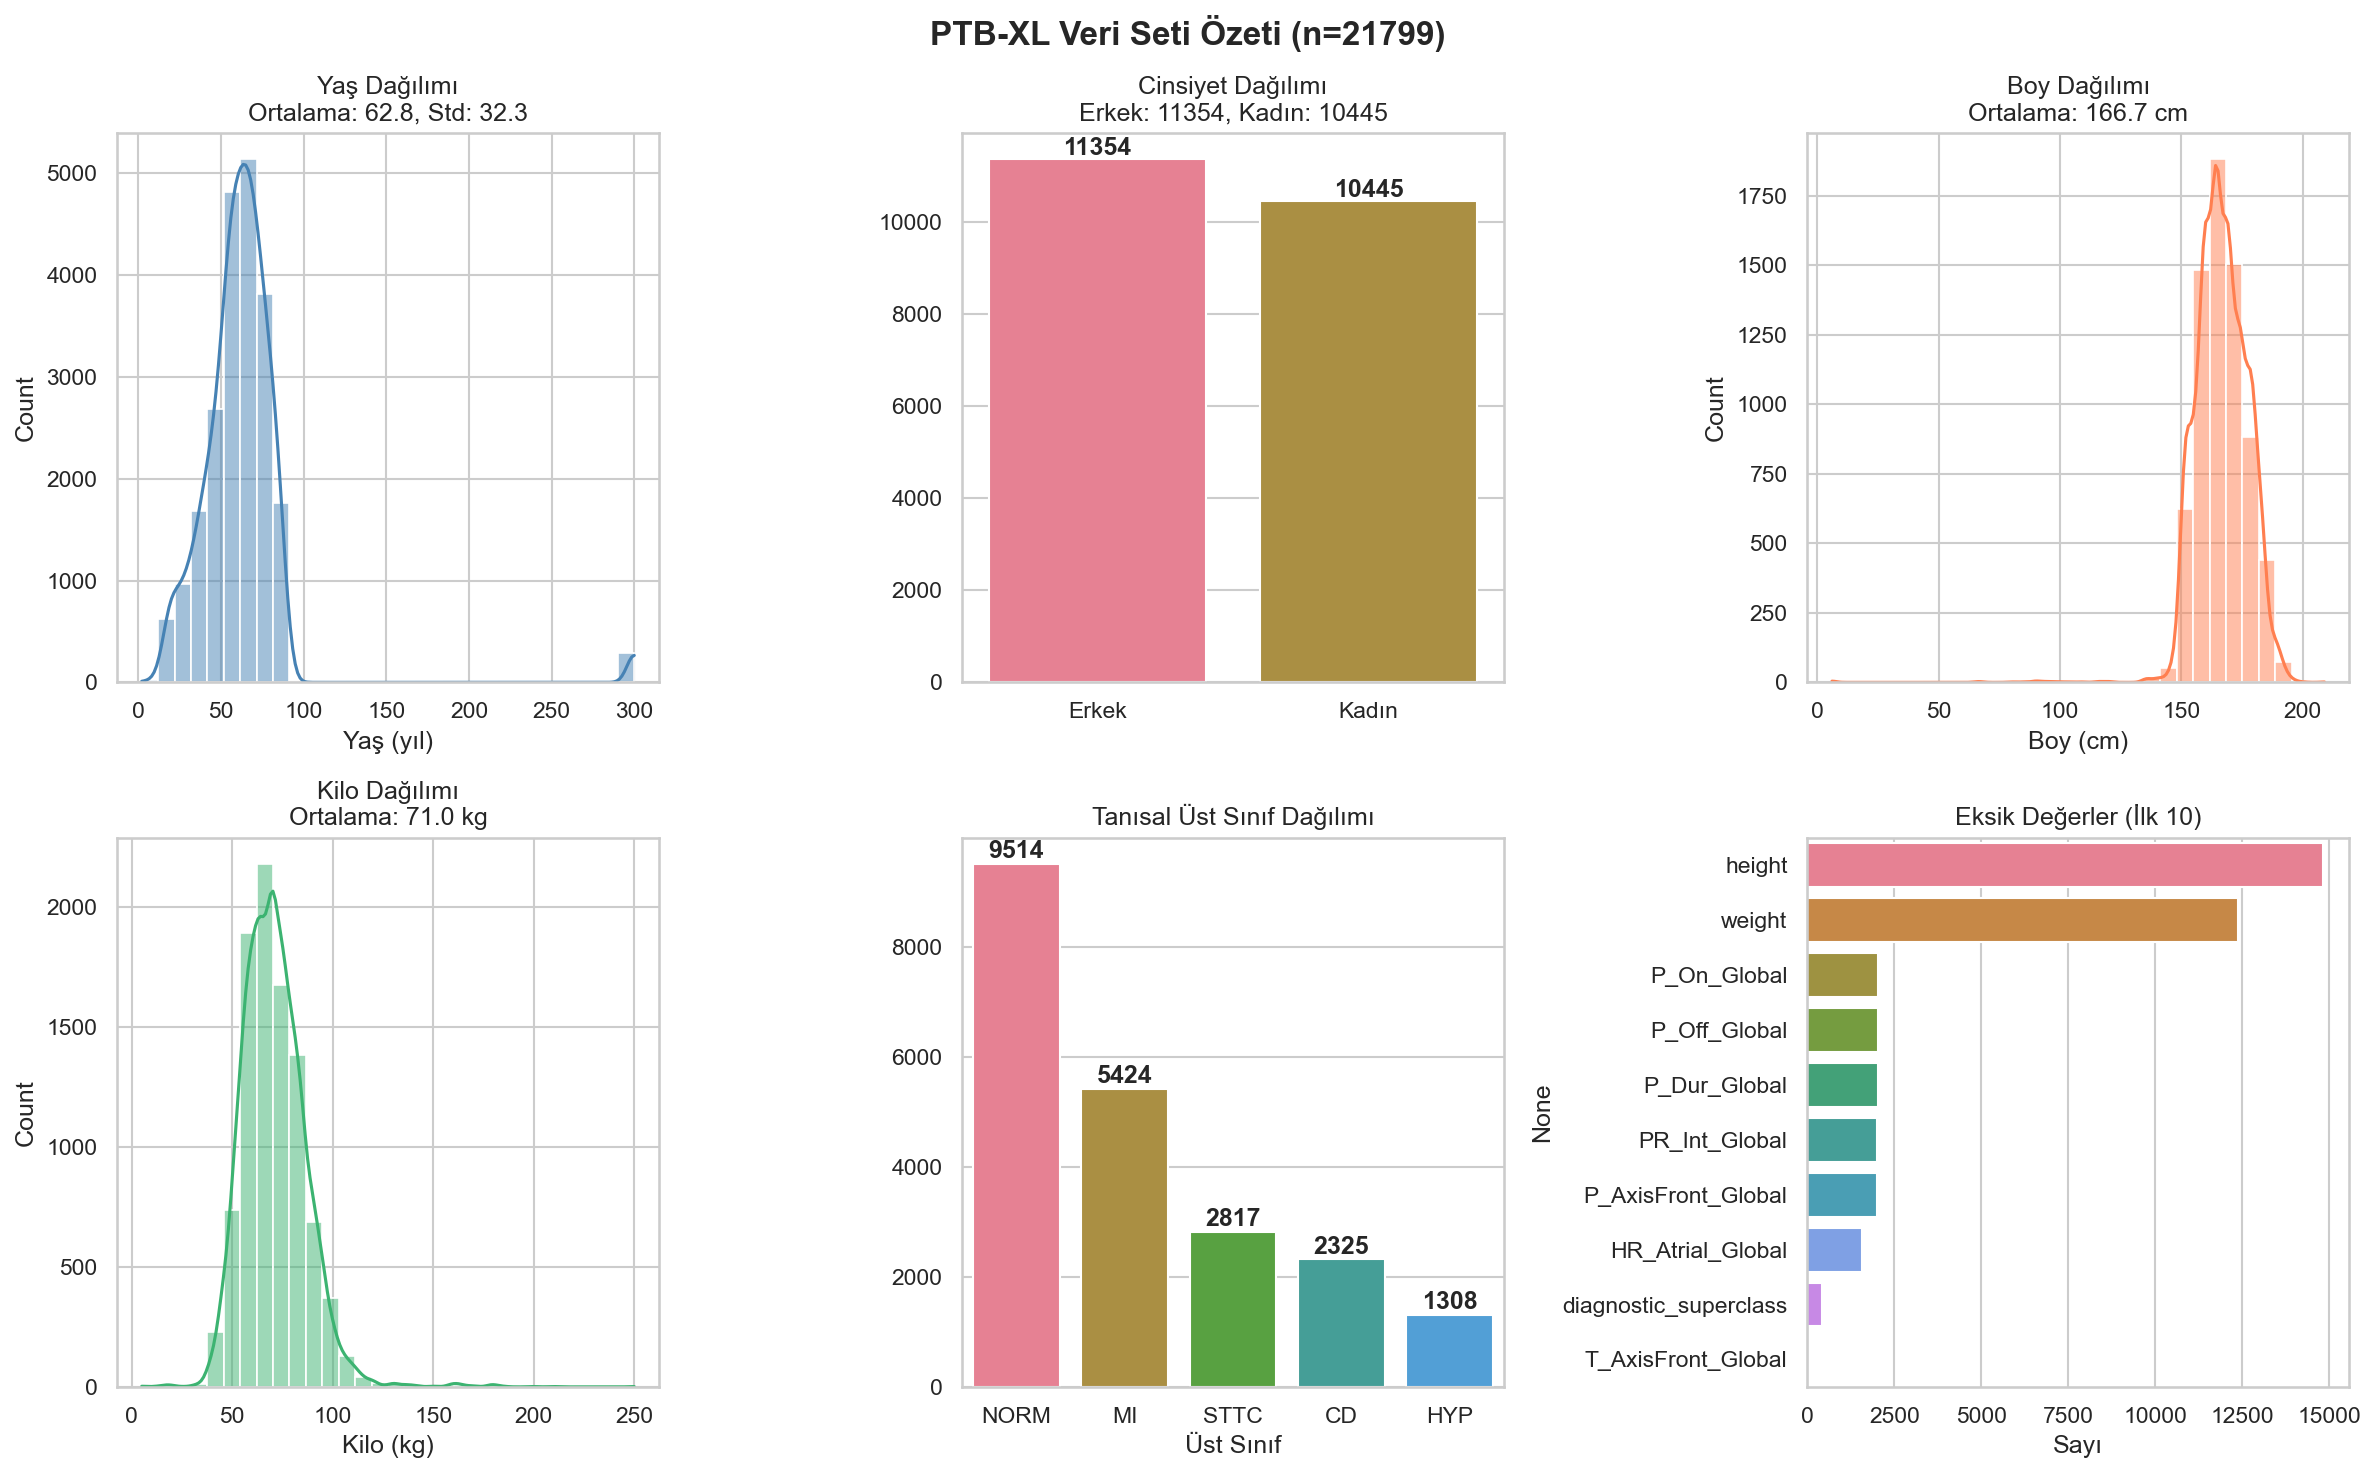

In [6]:
# Veri seti genel görünümü: yaş, cinsiyet, boy, kilo, tanısal sınıf, eksik değerler
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f"PTB-XL Veri Seti Özeti (n={len(df)})", fontsize=16, fontweight="bold")

# Yaş dağılımı
sns.histplot(df["age"].dropna(), bins=30, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title(f"Yaş Dağılımı\nOrtalama: {df['age'].mean():.1f}, Std: {df['age'].std():.1f}")
axes[0, 0].set_xlabel("Yaş (yıl)")

# Cinsiyet dağılımı (0=Erkek, 1=Kadın)
sex_counts = df["sex"].value_counts()
sex_labels = ["Erkek" if x == 0 else "Kadın" for x in sex_counts.index]
sns.barplot(x=sex_labels, y=sex_counts.values, ax=axes[0, 1], hue=sex_labels, legend=False)
axes[0, 1].set_title(f"Cinsiyet Dağılımı\nErkek: {sex_counts.get(0, 0)}, Kadın: {sex_counts.get(1, 0)}")
for i, v in enumerate(sex_counts.values):
    axes[0, 1].text(i, v + 100, str(v), ha="center", fontweight="bold")

# Boy dağılımı
sns.histplot(df["height"].dropna(), bins=30, kde=True, ax=axes[0, 2], color="coral")
axes[0, 2].set_title(f"Boy Dağılımı\nOrtalama: {df['height'].mean():.1f} cm")
axes[0, 2].set_xlabel("Boy (cm)")

# Kilo dağılımı
sns.histplot(df["weight"].dropna(), bins=30, kde=True, ax=axes[1, 0], color="mediumseagreen")
axes[1, 0].set_title(f"Kilo Dağılımı\nOrtalama: {df['weight'].mean():.1f} kg")
axes[1, 0].set_xlabel("Kilo (kg)")

# Tanısal üst sınıf dağılımı
superclass_counts = df["diagnostic_superclass"].value_counts()
sns.barplot(x=superclass_counts.index, y=superclass_counts.values, ax=axes[1, 1], hue=superclass_counts.index, legend=False)
axes[1, 1].set_title("Tanısal Üst Sınıf Dağılımı")
axes[1, 1].set_xlabel("Üst Sınıf")
for i, v in enumerate(superclass_counts.values):
    axes[1, 1].text(i, v + 100, str(v), ha="center", fontweight="bold")

# Eksik değerler
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
if len(missing_counts) > 0:
    top_missing = missing_counts.head(10)
    sns.barplot(x=top_missing.values, y=top_missing.index, ax=axes[1, 2], hue=top_missing.index, legend=False)
    axes[1, 2].set_title("Eksik Değerler (İlk 10)")
    axes[1, 2].set_xlabel("Sayı")
else:
    axes[1, 2].text(0.5, 0.5, "Eksik Değer Yok", ha="center", va="center", fontsize=14)
    axes[1, 2].set_title("Eksik Değerler")

plt.tight_layout()
plt.show()

In [7]:
print("male persentage: ", round(sex_counts[0] / sex_counts.sum() * 100, 1))
print("female persentage: ", round(sex_counts[1] / sex_counts.sum() * 100, 1)) 

male persentage:  52.1
female persentage:  47.9


In [8]:
len(numeric_cols)

NameError: name 'numeric_cols' is not defined

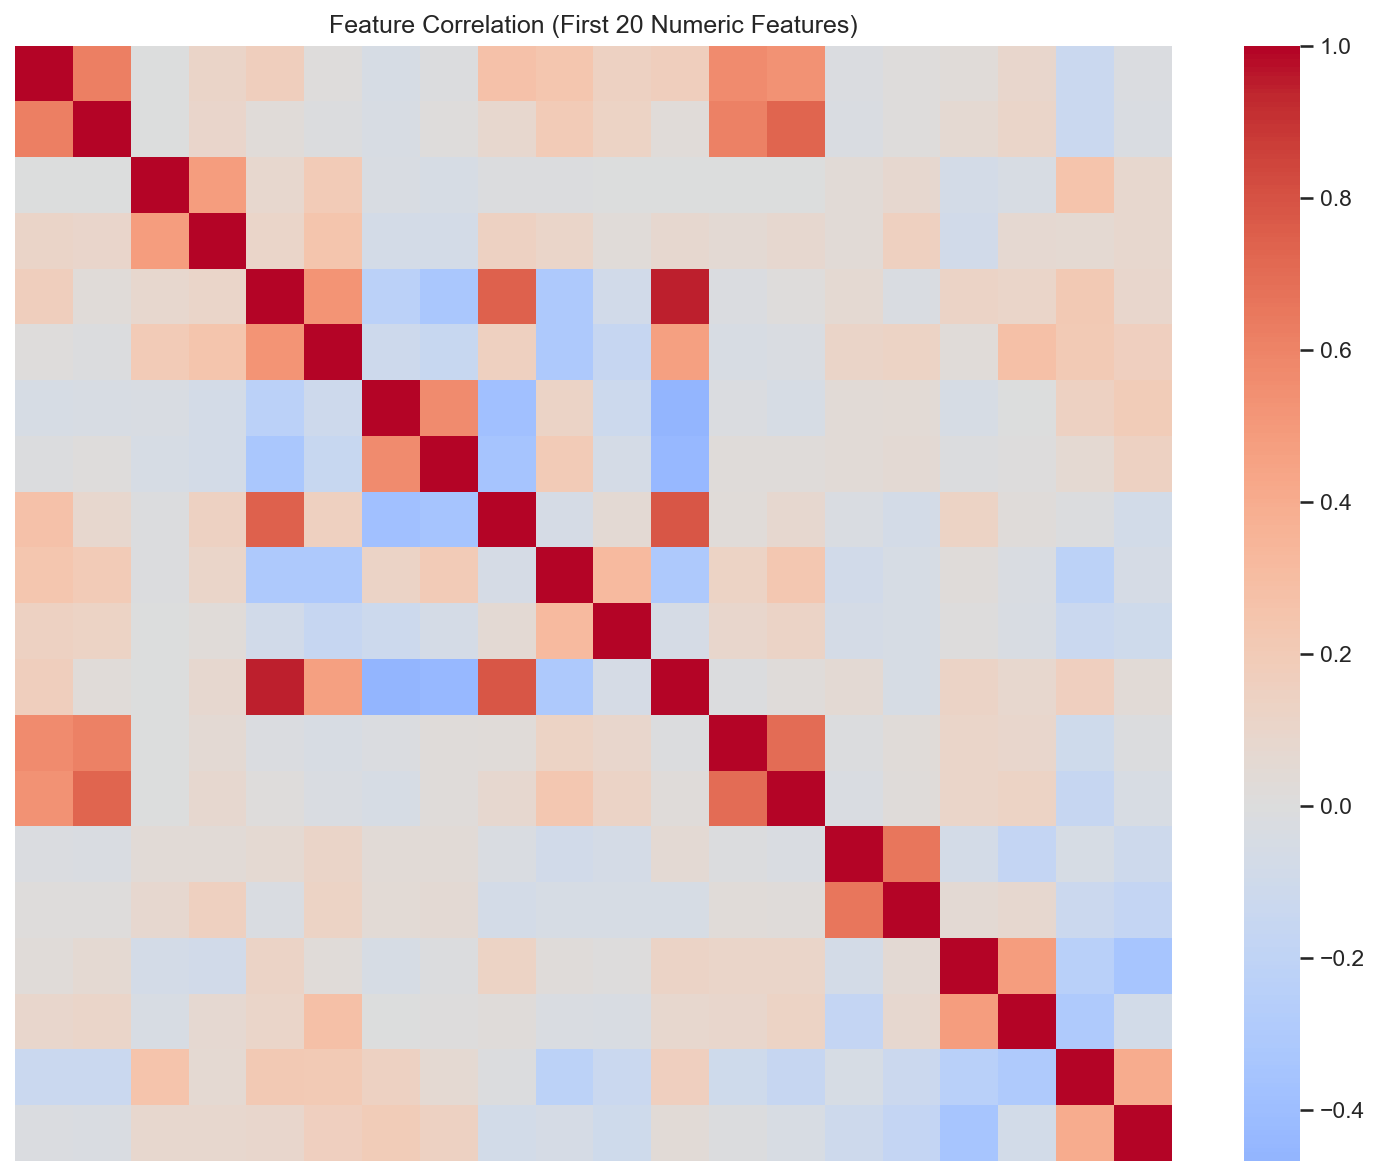

In [ ]:
# İlk n sayısal öznitelik için korelasyon ısı haritası

# number of feutures: 
n = 20
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:
    subset_cols = numeric_cols[:n]
    corr_matrix = df[subset_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)
    plt.title(f"Feature Correlation (First {len(subset_cols)} Numeric Features)")
    plt.tight_layout()
    plt.show()
else:
    print("Sayısal öznitelik bulunamadı.")

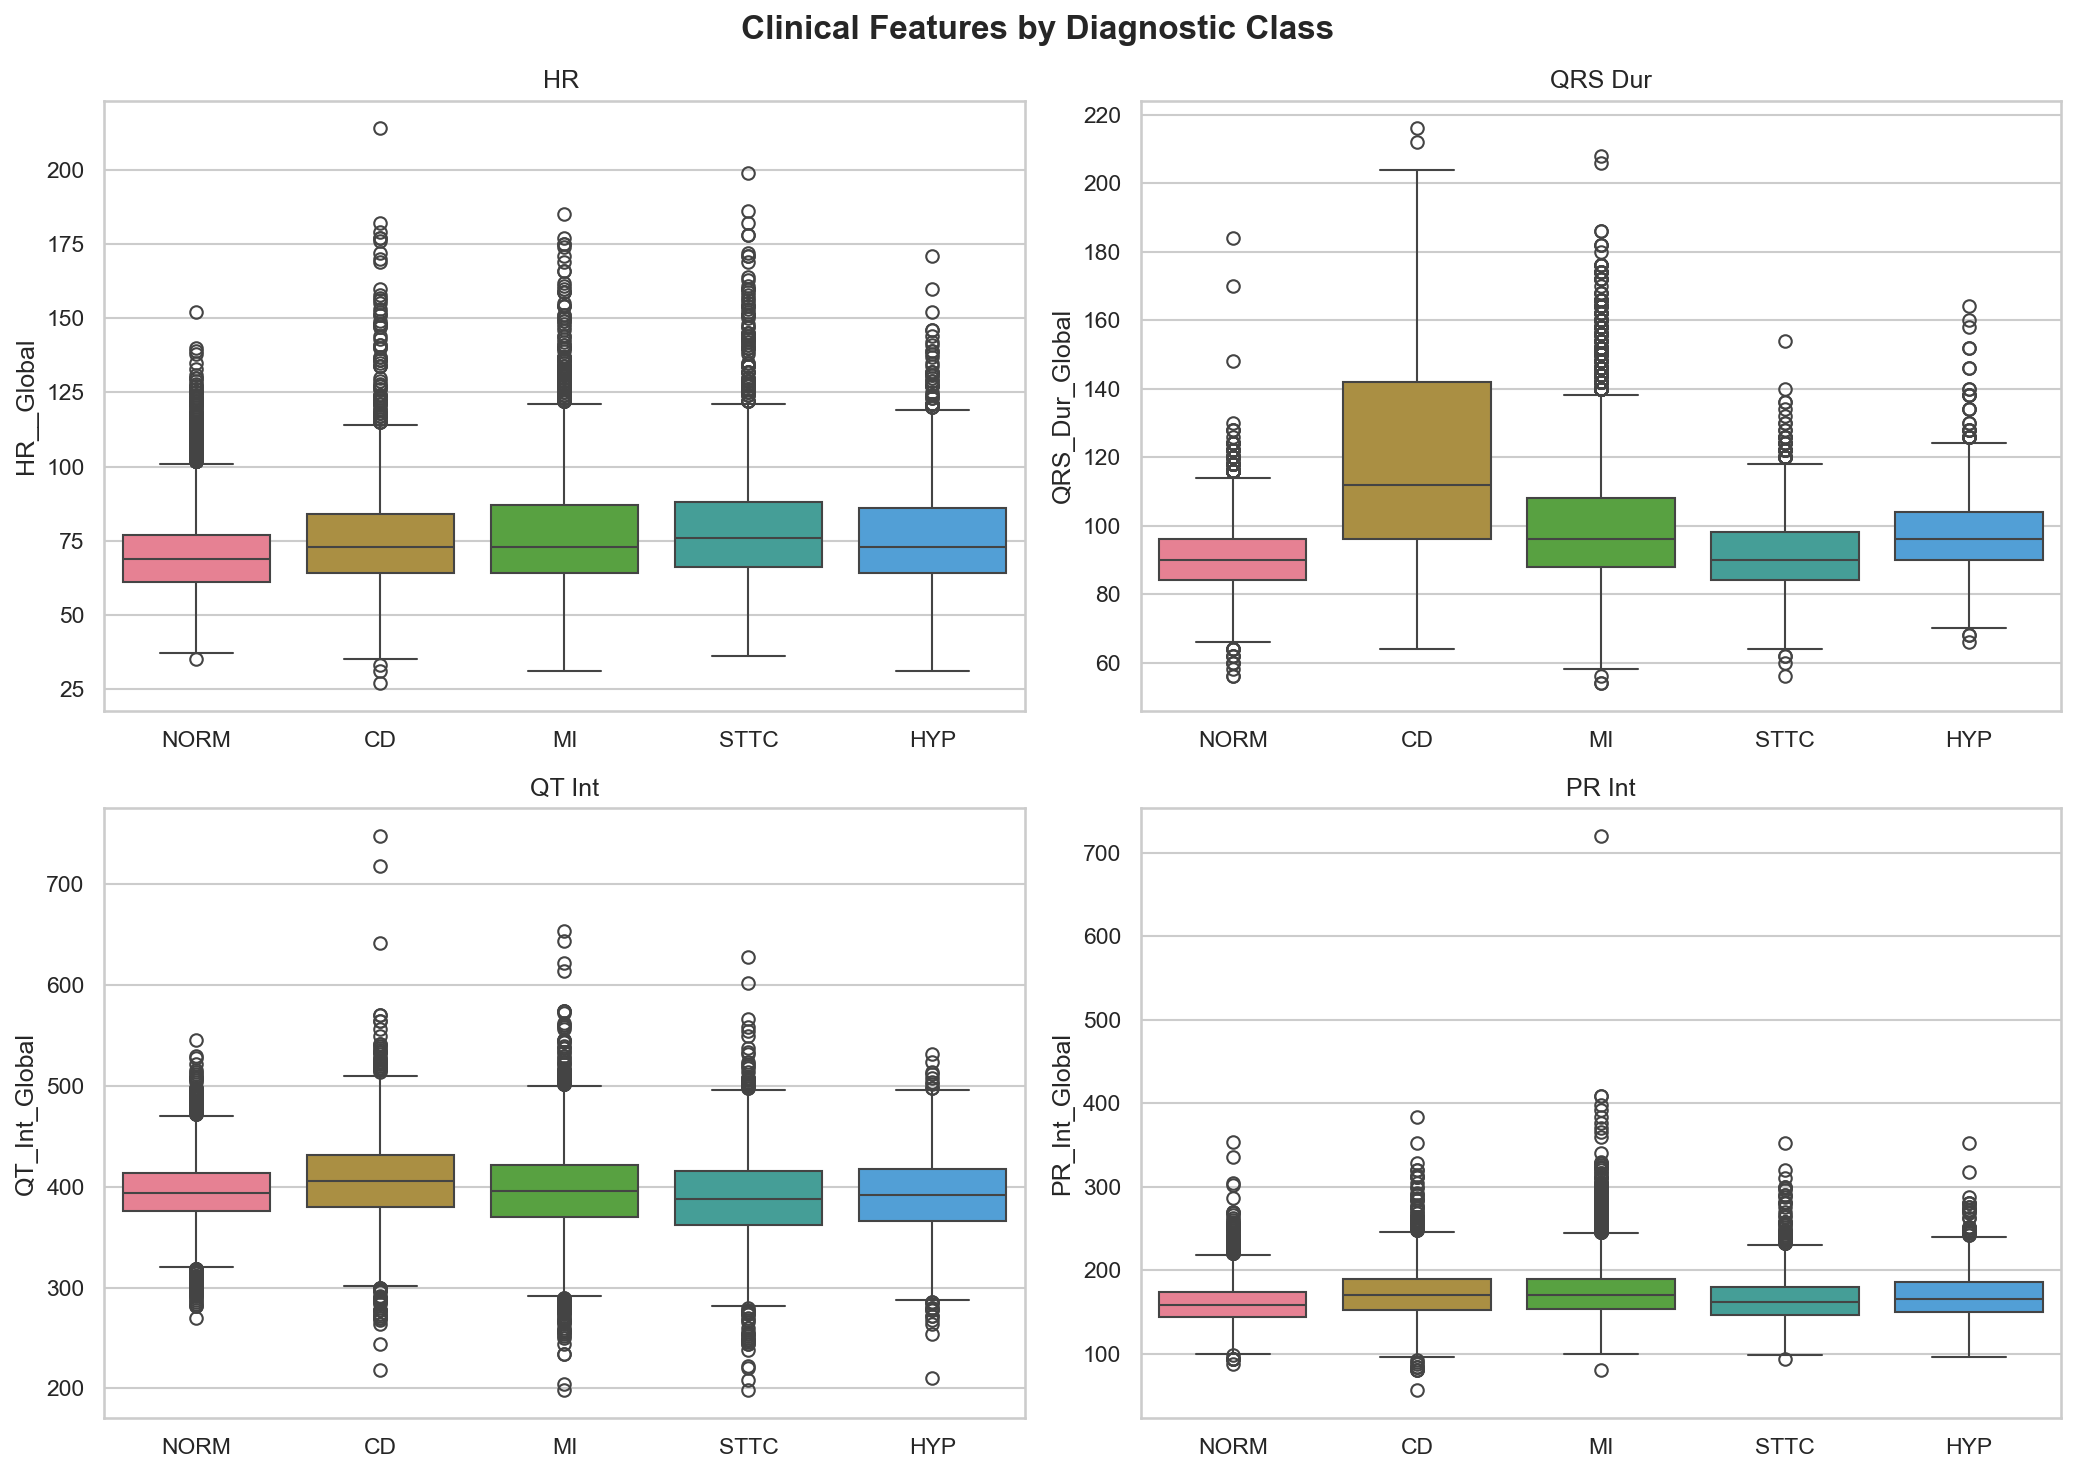

In [ ]:
# Tanısal sınıfa göre bazı klinik öznitelikler
clinical_features = [
    "HR__Global",
    "QRS_Dur_Global",
    "QT_Int_Global",
    "PR_Int_Global",
    "P_Dur_Global",
    "P_AxisFront_Global",
    "R_AxisFrontal_Global",
    "T_AxisFront_Global",
]

available_feats = [f for f in clinical_features if f in df.columns]
if available_feats:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Clinical Features by Diagnostic Class", fontsize=16, fontweight="bold")
    plot_feats = available_feats[:4]
    for ax, feat in zip(axes.flat, plot_feats):
        sns.boxplot(data=df, x="diagnostic_superclass", y=feat, ax=ax, hue="diagnostic_superclass", legend=False)
        ax.set_title(feat.replace("_Global", "").replace("_", " "))
        ax.set_xlabel("")
    plt.tight_layout()
    plt.show()
else:
    print("Seçilen klinik öznitelikler veri setinde bulunamadı.")

C:\Users\Pc\AppData\Local\Temp\ipykernel_30060\2011955386.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, y="feature", x="missing_percent", palette="viridis", ax=ax)


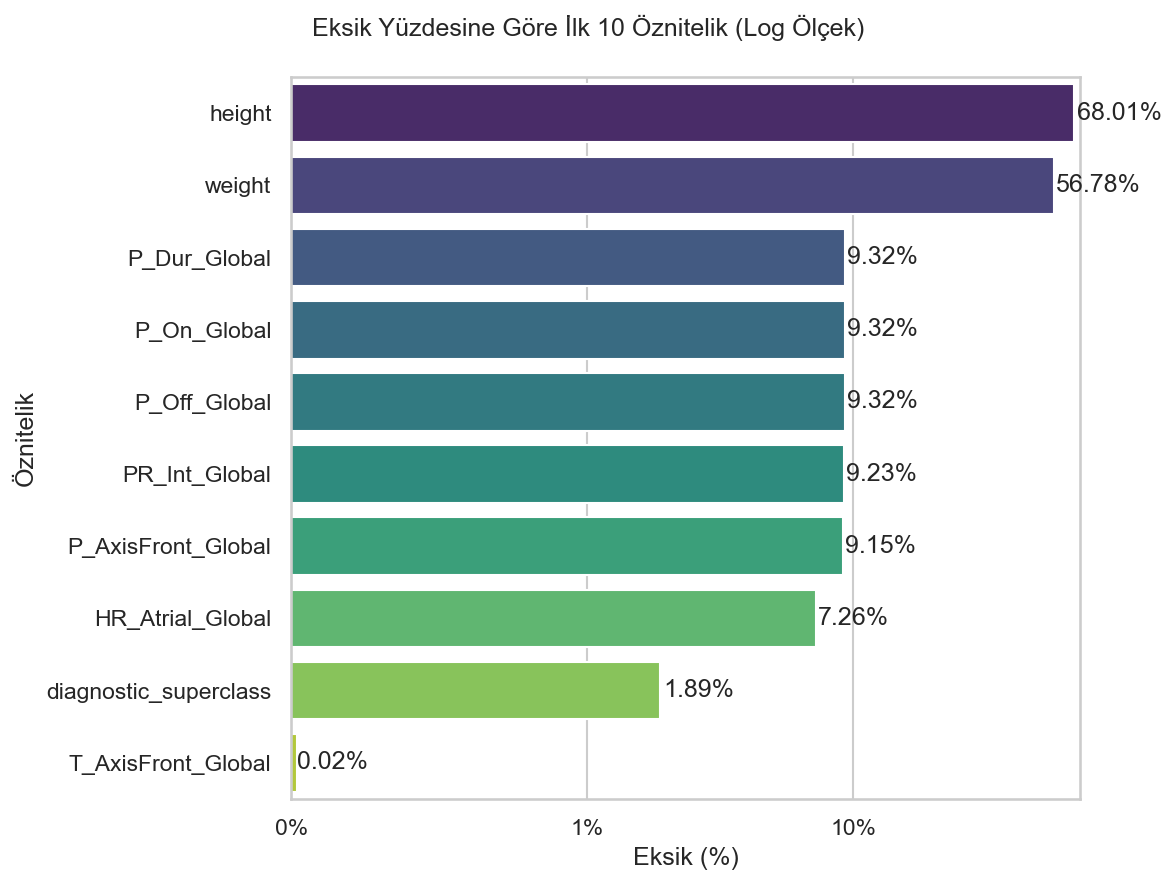

In [15]:
from matplotlib.ticker import PercentFormatter

# İlk 20 sütun için eksik değer tablolu özet
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
top20_missing_pct = missing_pct.sort_values(ascending=False).head(20)
top20_table = pd.DataFrame({
    "missing_count": df[top20_missing_pct.index].isnull().sum(),
    "missing_percent": top20_missing_pct
}).sort_values("missing_percent", ascending=False)

# Küçük yüzdeleri daha iyi göstermek için log-ölçekli x-ekseni
plot_df = top20_table[:10].reset_index().rename(columns={"index": "feature"})

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Eksik Yüzdesine Göre İlk 10 Öznitelik (Log Ölçek)", fontsize=12)

sns.barplot(data=plot_df, y="feature", x="missing_percent", palette="viridis", ax=ax)
ax.set_xscale("symlog", linthresh=1)  # 1% altı lineer, üstü log
ax.set_xlabel("Eksik (%)")
ax.set_ylabel("Öznitelik")

# Yüzde biçiminde gösterim ve okunabilir etiketler
ax.xaxis.set_major_formatter(PercentFormatter(100))

for p in ax.patches:
    width = p.get_width()
    ax.text(width * 1.02, p.get_y() + p.get_height() / 2, f"{width:.2f}%", va="center")

plt.tight_layout()
plt.show()


In [ ]:
# diğer istatistikler
print("=== Ek İstatistikler ===")
total_missing = missing.sum()
total_cells = df.size
print(f"Toplam hücre sayısı: {total_cells}")
print(f"Toplam eksik hücre sayısı: {total_missing}")
print(f"Toplam eksik hücre yüzdesi: {total_missing / total_cells * 100:.2f}%")

=== Ek İstatistikler ===
Toplam hücre sayısı: 17199411
Toplam eksik hücre sayısı: 39304
Toplam eksik hücre yüzdesi: 0.23%


In [ ]:
# Elle verilen eksik değer özetini tablo olarak yazdırma
missing_table = pd.DataFrame([
    {"feature": "height", "missing_count": 14825, "missing_percent": 68.01},
    {"feature": "weight", "missing_count": 12378, "missing_percent": 56.78},
    {"feature": "P_Dur_Global", "missing_count": 2032, "missing_percent": 9.32},
    {"feature": "P_On_Global", "missing_count": 2032, "missing_percent": 9.32},
    {"feature": "P_Off_Global", "missing_count": 2032, "missing_percent": 9.32},
    {"feature": "PR_Int_Global", "missing_count": 2013, "missing_percent": 9.23},
    {"feature": "P_AxisFront_Global", "missing_count": 1994, "missing_percent": 9.15},
    {"feature": "HR_Atrial_Global", "missing_count": 1582, "missing_percent": 7.26},
    {"feature": "diagnostic_superclass", "missing_count": 411, "missing_percent": 1.89},
    {"feature": "T_AxisFront_Global", "missing_count": 4, "missing_percent": 0.02},
    {"feature": "Sp_Area_aVR", "missing_count": 0, "missing_percent": 0.00},
    {"feature": "ST_Amp116_aVR", "missing_count": 0, "missing_percent": 0.00},
    {"feature": "ST_Amp_aVR", "missing_count": 0, "missing_percent": 0.00},
    {"feature": "Sp_PeakTime_aVR", "missing_count": 0, "missing_percent": 0.00},
    {"feature": "T_AreaFull_aVL", "missing_count": 0, "missing_percent": 0.00},
    {"feature": "Sp_Dur_aVR", "missing_count": 0, "missing_percent": 0.00},
    {"feature": "Sp_Amp_aVR", "missing_count": 0, "missing_percent": 0.00},
    {"feature": "Rp_PeakTime_aVR", "missing_count": 0, "missing_percent": 0.00},
    {"feature": "Rp_Area_aVR", "missing_count": 0, "missing_percent": 0.00},
    {"feature": "Rp_Amp_aVR", "missing_count": 0, "missing_percent": 0.00},
]).sort_values("missing_percent", ascending=False)

# Yüzde formatı ile göster
missing_table.style.format({"missing_percent": "{:.2f}%"})

,feature,missing_count,missing_percent
0,height,14825,68.01%
1,weight,12378,56.78%
2,P_Dur_Global,2032,9.32%
3,P_On_Global,2032,9.32%
4,P_Off_Global,2032,9.32%
5,PR_Int_Global,2013,9.23%
6,P_AxisFront_Global,1994,9.15%
7,HR_Atrial_Global,1582,7.26%
8,diagnostic_superclass,411,1.89%
9,T_AxisFront_Global,4,0.02%
